# Project 1: Multi-Model Sentiment Ensemble
----------
## Notebook 1: Exploratory Data Analysis & VADER Baseline

This notebook covers:
- Stage 1: Loading and exploring the TweetEval dataset
- Stage 2: VADER sentiment baseline — lexicon-based classification and failure analysis

### Stage 1: Exploratory Data Analysis

In [4]:
# Load datasets
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text analysis
import re

# Display settings
pd.set_option('display.max_colwidth', 100)
%matplotlib inline

In [6]:
sentiment = load_dataset('tweet_eval', 'sentiment')
hate = load_dataset('tweet_eval', 'hate')

In [8]:
print(sentiment)
print(hate)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2970
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
})


Notice that sentiment and hate are DatasetDicts already broken into train, test, and val splits.

In [9]:
# Check label mappings
print("Sentiment labels:", sentiment['train'].features['label'].names)
print("Hate labels:", hate['train'].features['label'].names)

Sentiment labels: ['negative', 'neutral', 'positive']
Hate labels: ['non-hate', 'hate']


In [32]:
# Convert to pandas for easier exploration
sentiment_train = pd.DataFrame(sentiment['train'])
hate_train = pd.DataFrame(hate['train'])

# Print 10 examples from each class
print("=== SENTIMENT SAMPLES ===")
for label_id in [0, 1, 2]:
    print(f"\n--- Class {label_id} ---")
    
    # Filter the dataframe to only rows where label matches our target class
    matching_rows = sentiment_train[sentiment_train['label'] == label_id]
    
    # Randomly sample 5 rows from those matching rows
    samples = matching_rows.sample(n=10, random_state=42)
    for index, row in samples.iterrows():
        print(f"  [{index}] {row['text']}")

print("\n=== HATE SAMPLES ===")
for label_id in [0, 1]:
    print(f"\n--- Class {label_id} ---")

    # Filter the dataframe to only rows where label matches our target class
    matching_rows = hate_train[hate_train['label'] == label_id]
    
    # Randomly sample 5 rows from those matching rows
    samples = matching_rows.sample(n=10, random_state=42)
    for index, row in samples.iterrows():
        print(f"  [{index}] {row['text']}")

=== SENTIMENT SAMPLES ===

--- Class 0 ---
  [4939] "#CNET - Just bought my 1st iPad, iPad3, feeling real burned, mad, about iPad4 so soon. Grrr. REALLY mad! Don't even care about mini now,"
  [15545] "Mother's Day is coming like tomorrow or is it today? idk, but i didn't prepare anything for me's mom."
  [10440] Can't believe I left my charger at Tia's. I have just under 50% until tomorrow, so in living on my IPod. You can only contact me via Twitter
  [13852] If I didn't yell at someone about Taylor Swift or Kesha then the entire day was a waste. Try to be better tomorrow.
  [9042] @user @user Nice Try - but why do you #LIE! (#Obama lies2) "Planned Parenthood does not provide mammograms"
  [10259] Oh shit Nicki and Mikey gone be in the same room tomorrow I wonder if Mikey gone talk all that shit then #VMAs
  [15571] Why does everything have to be compared with Muslims. At just 13% more non-Muslims eat meat than Muslims in India.
  [20961] @user done and done! I haven't seen the last 

The above data is messy in realistic ways, stray letters, @user placeholders, hashtags, mixed case.

##### Continuing on to...
------
### Class Distribution for Both Datasets

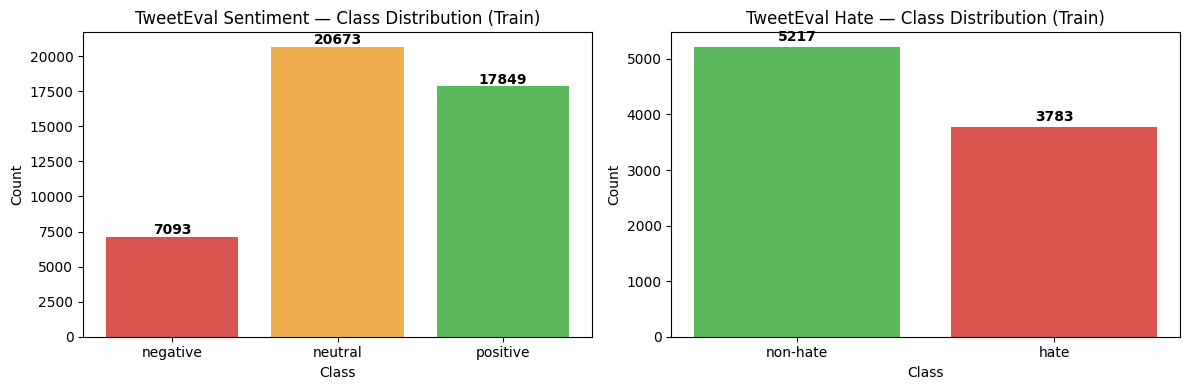

Sentiment class counts: {0: 7093, 1: 20673, 2: 17849}
Hate class counts: {0: 5217, 1: 3783}


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sentiment distribution
sentiment_counts = sentiment_train['label'].value_counts().sort_index()
axes[0].bar(['negative', 'neutral', 'positive'], sentiment_counts.values, color=['#d9534f', '#f0ad4e', '#5cb85c'])
axes[0].set_title('TweetEval Sentiment — Class Distribution (Train)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Hate distribution
hate_counts = hate_train['label'].value_counts().sort_index()
axes[1].bar(['non-hate', 'hate'], hate_counts.values, color=['#5cb85c', '#d9534f'])
axes[1].set_title('TweetEval Hate — Class Distribution (Train)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
for i, v in enumerate(hate_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sentiment class counts:", sentiment_counts.to_dict())
print("Hate class counts:", hate_counts.to_dict())

See above that the sentiment dataset is imbalanced. There are fewer negative samples. The hate dataset is less imbalanced.

When considering evaluation metrics, we must consider whether the dataset is imbalanced. In imbalanced data, accuracy becomes misleading. A model that predicts neutral for every tweet of the sentiment datawset would get 45% accuracy yet be useless!
- F1 macro: computes F1 per class and then averages them, treating each class equally regardless of size. Penalizes model for ignoring minority class
- Confusion matrix

When data is balanced:
- ROC-AUC: plots true positive curve (recall) vs false positive rate as you sweep threshold from 0 to 1. AUC summarizes it as a single number from 0.5 (random) to 1.0 (perfect).
- Precision: measure of reproducibility and reliabilty
- Recall: ratio of relevant correctly identified items to total number of relevant items


##### For this experiment, we will use all metrics, but will consider the balance of the classes when reviewing metrics!

----------
### Basic Text Statistics

In [25]:
def avg_token_count(df):
    token_counts = []
    
    for tweet in df['text']:
        # Split the tweet into individual words
        words = tweet.split()
        # Count how many words are in this tweet
        word_count = len(words)
        # Add that count to our list
        token_counts.append(word_count)
    
    # Calculate the average across all tweets
    average = sum(token_counts) / len(token_counts)
    return average

print(f"Sentiment average token count: {avg_token_count(sentiment_train):.1f}")
print(f"Hate average token count: {avg_token_count(hate_train):.1f}")

Sentiment average token count: 19.2
Hate average token count: 20.8


In [26]:
def count_urls(df):
    url_pattern = r'http\S+'
    
    url_counts = []
    
    for tweet in df['text']:
        # Search for anything that starts with 'http' followed by non-whitespace characters
        urls_found = re.findall(url_pattern, tweet)
        
        # Does this tweet contain at least one URL? True or False
        has_url = len(urls_found) > 0
        
        url_counts.append(has_url)
    
    # Count how many Trues present and divide by total tweets
    percentage = sum(url_counts) / len(url_counts) * 100
    return percentage

print(f"Sentiment train % with URLs: {count_urls(sentiment_train):.1f}%")
print(f"Hate train % with URLs: {count_urls(hate_train):.1f}%")

Sentiment train % with URLs: 0.2%
Hate train % with URLs: 1.4%


It's possible that TweetEval already stripped URLs from some tweets during preprocessing.

In [27]:
def count_mentions(df):
    mention_counts = []
    
    for tweet in df['text']:
        # Find anything that starts with @ followed by non-whitespace characters
        mentions_found = re.findall(r'@\S+', tweet)
        
        # Does this tweet contain at least one mention?
        has_mention = len(mentions_found) > 0
        
        mention_counts.append(has_mention)
    
    count = sum(mention_counts)
    percentage = count / len(mention_counts) * 100
    return count, percentage


def count_hashtags(df):
    hashtag_counts = []
    
    for tweet in df['text']:
        # Find anything that starts with # followed by non-whitespace characters
        hashtags_found = re.findall(r'#\S+', tweet)
        
        # Does this tweet contain at least one hashtag?
        has_hashtag = len(hashtags_found) > 0
        
        hashtag_counts.append(has_hashtag)
    
    count = sum(hashtag_counts)
    percentage = count / len(hashtag_counts) * 100
    return count, percentage

In [28]:
# Sentiment
s_mention_count, s_mention_pct = count_mentions(sentiment_train)
s_hashtag_count, s_hashtag_pct = count_hashtags(sentiment_train)

print("=== SENTIMENT TRAIN ===")
print(f"Tweets with @ mentions: {s_mention_count} ({s_mention_pct:.1f}%)")
print(f"Tweets with hashtags:   {s_hashtag_count} ({s_hashtag_pct:.1f}%)")

# Hate
h_mention_count, h_mention_pct = count_mentions(hate_train)
h_hashtag_count, h_hashtag_pct = count_hashtags(hate_train)

print("\n=== HATE TRAIN ===")
print(f"Tweets with @ mentions: {h_mention_count} ({h_mention_pct:.1f}%)")
print(f"Tweets with hashtags:   {h_hashtag_count} ({h_hashtag_pct:.1f}%)")

=== SENTIMENT TRAIN ===
Tweets with @ mentions: 13430 (29.4%)
Tweets with hashtags:   8538 (18.7%)

=== HATE TRAIN ===
Tweets with @ mentions: 3497 (38.9%)
Tweets with hashtags:   2323 (25.8%)


In [29]:
def count_all_caps(df):
    has_caps_list = []
    caps_count_list = []
    
    for tweet in df['text']:
        # Split into words and find ones that are all caps
        # We require length > 1 to exclude single letters like "I" or "A"
        words = tweet.split()
        caps_words = [word for word in words if word.isupper() and len(word) > 1]
        
        # Does this tweet have at least one all-caps word?
        has_caps = len(caps_words) > 0
        
        has_caps_list.append(has_caps)
        caps_count_list.append(len(caps_words))
    
    pct_with_caps = sum(has_caps_list) / len(has_caps_list) * 100
    avg_caps_per_tweet = sum(caps_count_list) / len(caps_count_list)
    
    return pct_with_caps, avg_caps_per_tweet

s_caps_pct, s_caps_avg = count_all_caps(sentiment_train)
h_caps_pct, h_caps_avg = count_all_caps(hate_train)

print("=== SENTIMENT TRAIN ===")
print(f"Tweets with at least one ALL CAPS word: {s_caps_pct:.1f}%")
print(f"Avg ALL CAPS words per tweet: {s_caps_avg:.2f}")

print("\n=== HATE TRAIN ===")
print(f"Tweets with at least one ALL CAPS word: {h_caps_pct:.1f}%")
print(f"Avg ALL CAPS words per tweet: {h_caps_avg:.2f}")

=== SENTIMENT TRAIN ===
Tweets with ALL CAPS words: 32.1%
Avg ALL CAPS words per tweet: 0.53

=== HATE TRAIN ===
Tweets with ALL CAPS words: 29.9%
Avg ALL CAPS words per tweet: 0.79


In [30]:
def count_entirely_caps(df):
    entirely_caps_list = []
    
    for tweet in df['text']:
        # Split into words, filter out non-alphabetic tokens like URLs, mentions, hashtags
        words = tweet.split()
        alpha_words = [word for word in words if word.isalpha() and len(word) > 1]
        
        # If there are no alphabetic words, skip this tweet
        if len(alpha_words) == 0:
            entirely_caps_list.append(False)
            continue
        
        # Is every alphabetic word in the tweet all caps?
        all_caps = all(word.isupper() for word in alpha_words)
        entirely_caps_list.append(all_caps)
    
    count = sum(entirely_caps_list)
    percentage = count / len(entirely_caps_list) * 100
    return count, percentage

s_all_count, s_all_pct = count_entirely_caps(sentiment_train)
h_all_count, h_all_pct = count_entirely_caps(hate_train)

print("=== SENTIMENT TRAIN ===")
print(f"Entirely caps tweets: {s_all_count} ({s_all_pct:.1f}%)")

print("\n=== HATE TRAIN ===")
print(f"Entirely caps tweets: {h_all_count} ({h_all_pct:.1f}%)")

=== SENTIMENT TRAIN ===
Entirely caps tweets: 0 (0.0%)

=== HATE TRAIN ===
Entirely caps tweets: 123 (1.4%)


Note that non-alphabetic tokens are filtered out in the above.

-------------
## Stage 2: VADER Baseline

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon-based sentiment 
tool — it uses a hand-crafted dictionary of words with pre-assigned sentiment scores 
rather than learned parameters. No training, no GPU, no model weights.

It returns four scores for any input text:
- **pos**: proportion of text that is positive
- **neg**: proportion of text that is negative  
- **neu**: proportion of text that is neutral
- **compound**: normalized aggregate score from -1 (most negative) to +1 (most positive)

Threshold the compound score for three-class prediction:
- compound >= 0.05 → positive
- compound <= -0.05 → negative
- everything else → neutral

This is our baseline — every subsequent model must beat this to justify its added complexity.

How does it work?
- VADER looks at every word in the tweet and looks it up in its dictionary
- Each word has a pre-assigned score — "love" might be +3.2, "hate" might be -2.8, "the" is 0
- It adds those scores up, adjusts for things like ALL CAPS and punctuation (exclamation marks boost intensity), and normalizes the result to sit between -1 and +1

For example, for a tweet like "I LOVE this so much!!!" the positive word scores plus the caps boost plus the exclamation marks might produce a compound of +0.85.

How does VADER normalize?

VADER normalizes the raw sum using this:
> $compound = \frac{x}{\sqrt{x^2 + \alpha}}$

Where:
- x is the raw sum of all the word scores added together
- α (alpha) is a normalization constant set to 15 in the original VADER paper

VADER's formula is a custom design choice by its authors. They wanted something that:
- Always stays bounded between -1 and +1
- Handles text of any length gracefully (a 3 word tweet vs a 30 word tweet both produce comparable scores)
- Saturates smoothly rather than clipping hard at the boundaries

The α = 15 constant was empirically tuned via hyperparameter sweep.

In [48]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
import time

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Run VADER on the full sentiment test split
sentiment_test = pd.DataFrame(sentiment['test'])

vader_predictions = []
vader_compounds = []

for tweet in sentiment_test['text']:
    # run VADER scoring process on this text, looks up every word in dictionary, applied modifier rules (caps, punctuation)
    # computes normalization formula, returns all scores as a python dict like:
    # {'neg': 0.0, 'neu': 0.287, 'pos': 0.713, 'compound': 0.8316}
    scores = sia.polarity_scores(tweet)

    # Pull out the compound value from the dictionary
    compound = scores['compound']
    vader_compounds.append(compound)
    
    # Apply threshold rules to append predictions
    if compound >= 0.05:
        vader_predictions.append(2)  # positive
    elif compound <= -0.05:
        vader_predictions.append(0)  # negative
    else:
        vader_predictions.append(1)  # neutral

# Store results in the test dataframe
sentiment_test['vader_compound'] = vader_compounds
sentiment_test['vader_prediction'] = vader_predictions

## VADER Metrics

I evaluate on the full sentiment test split using accuracy, F1-macro, and a confusion matrix.
F1-macro is our primary metric because the sentiment dataset is imbalanced; neutral dominates 
at 45% of training examples.

In [57]:
true_labels = sentiment_test['label'].tolist()

# Accuracy
accuracy = accuracy_score(true_labels, vader_predictions)

# F1-macro — treats each class equally regardless of size
f1_macro = f1_score(true_labels, vader_predictions, average='macro')

# F1 per class
f1_per_class = f1_score(true_labels, vader_predictions, average=None)

# Confusion matrix
cm = confusion_matrix(true_labels, vader_predictions)

hate_true_labels = hate_test['label'].tolist()

sentiment_precision = precision_score(true_labels, vader_predictions, average=None)
sentiment_recall = recall_score(true_labels, vader_predictions, average=None)

print(f"Accuracy:     {accuracy:.3f}")
print(f"F1-macro:     {f1_macro:.3f}")

print(f"\nF1 per class:")
print(f"  Negative:   {f1_per_class[0]:.3f}")
print(f"  Neutral:    {f1_per_class[1]:.3f}")
print(f"  Positive:   {f1_per_class[2]:.3f}")

print(f"\nPrecision per class:")
print(f"  Negative:   {sentiment_precision[0]:.3f}")
print(f"  Neutral:    {sentiment_precision[1]:.3f}")
print(f"  Positive:   {sentiment_precision[2]:.3f}")

print(f"\nRecall per class:")
print(f"  Negative:   {sentiment_recall[0]:.3f}")
print(f"  Neutral:    {sentiment_recall[1]:.3f}")
print(f"  Positive:   {sentiment_recall[2]:.3f}")

print(f"\nConfusion Matrix:")
print(cm)

Accuracy:     0.530
F1-macro:     0.529

F1 per class:
  Negative:   0.582
  Neutral:    0.530
  Positive:   0.474

Precision per class:
  Negative:   0.607
  Neutral:    0.675
  Positive:   0.355

Recall per class:
  Negative:   0.559
  Neutral:    0.437
  Positive:   0.714

Confusion Matrix:
[[2222  725 1025]
 [1283 2594 2060]
 [ 156  524 1695]]


Remember that precision and recall can be easier to misread in context of imbalanced datasets like sentiment.

- Neutral — high precision (0.675), terrible recall (0.437). VADER is confident when it predicts neutral but misses most actual neutral tweets, pushing them toward negative or positive instead.
- Positive — low precision (0.355), high recall (0.714). VADER catches most actual positive tweets but is trigger-happy, pulling in a lot of neutral tweets as positive false alarms.
- Negative — most balanced (precision 0.607, recall 0.559), which is why its F1 is the strongest of the three classes.

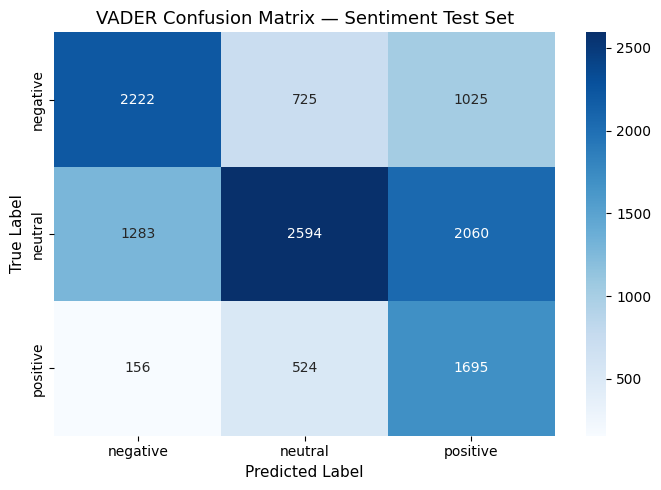

In [65]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative', 'neutral', 'positive'],   # predicted
    yticklabels=['negative', 'neutral', 'positive'],   # actual
    ax=ax
)

ax.set_title('VADER Confusion Matrix — Sentiment Test Set', fontsize=13)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('../results/figures/vader_sentiment_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## VADER on Hate Dataset

VADER was designed for sentiment detection, not hate speech. I apply it here as an 
experiment. This is a naive assumption and I expect it to perform poorly, but it serves as an important 
baseline that motivates the need for domain-specific models in Project 2.

Mapping:
- compound <= -0.05 → hate (class 1)
- everything else → non-hate (class 0)

In [55]:
hate_test = pd.DataFrame(hate['test'])

hate_vader_predictions = []
hate_vader_compounds = []

for tweet in hate_test['text']:
    scores = sia.polarity_scores(tweet)
    compound = scores['compound']
    hate_vader_compounds.append(compound)
    
    # Map negative sentiment to hate, everything else to non-hate
    if compound <= -0.05:
        hate_vader_predictions.append(1)  # hate
    else:
        hate_vader_predictions.append(0)  # non-hate

hate_test['vader_compound'] = hate_vader_compounds
hate_test['vader_prediction'] = hate_vader_predictions

# Metrics
hate_true_labels = hate_test['label'].tolist()

hate_accuracy = accuracy_score(hate_true_labels, hate_vader_predictions)
hate_f1_macro = f1_score(hate_true_labels, hate_vader_predictions, average='macro')
hate_f1_per_class = f1_score(hate_true_labels, hate_vader_predictions, average=None)
hate_precision = precision_score(hate_true_labels, hate_vader_predictions, average=None)
hate_recall = recall_score(hate_true_labels, hate_vader_predictions, average=None)
hate_cm = confusion_matrix(hate_true_labels, hate_vader_predictions)

print(f"Accuracy:     {hate_accuracy:.3f}")
print(f"F1-macro:     {hate_f1_macro:.3f}")
print(f"\nF1 per class:")
print(f"  Non-hate:   {hate_f1_per_class[0]:.3f}")
print(f"  Hate:       {hate_f1_per_class[1]:.3f}")
print(f"\nPrecision per class:")
print(f"  Non-hate:   {hate_precision[0]:.3f}")
print(f"  Hate:       {hate_precision[1]:.3f}")
print(f"\nRecall per class:")
print(f"  Non-hate:   {hate_recall[0]:.3f}")
print(f"  Hate:       {hate_recall[1]:.3f}")
print(f"\nConfusion Matrix:")
print(hate_cm)

Accuracy:     0.566
F1-macro:     0.564

F1 per class:
  Non-hate:   0.534
  Hate:       0.595

Precision per class:
  Non-hate:   0.706
  Hate:       0.491

Recall per class:
  Non-hate:   0.429
  Hate:       0.755

Confusion Matrix:
[[737 981]
 [307 945]]


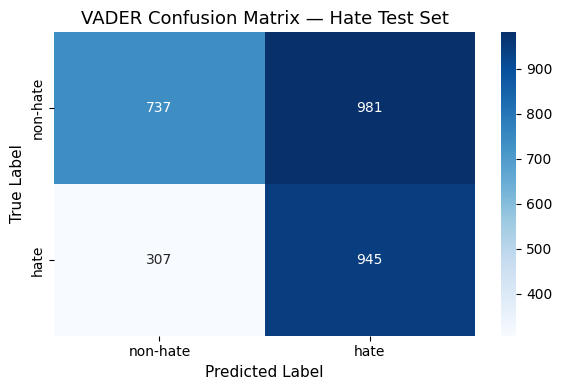

In [52]:
pythonfig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(
    hate_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['non-hate', 'hate'],   # predicted
    yticklabels=['non-hate', 'hate'],   # actual
    ax=ax
)

ax.set_title('VADER Confusion Matrix — Hate Test Set', fontsize=13)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('../results/figures/vader_hate_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Sentiment results (F1-macro: 0.529)
VADER is roughly coin-flip level on sentiment. A few things stand out:

- Negative F1 (0.582) is actually the strongest class despite being the minority. VADER's lexicon was originally designed for negative sentiment detection so this makes sense
- Positive F1 (0.474) is the weakest, likely because positive tweets on social media use slang and irony that VADER's dictionary doesn't handle well
- Looking at the confusion matrix, the biggest error cluster is neutral tweets being split between negative and positive with 1,283 neutral tweets predicted negative and 2,060 predicted positive. VADER is trigger-happy, pushing ambiguous tweets toward the extremes rather than the middle

Hate results (F1-macro: 0.564)
Note the precision/recall split:

- Non-hate precision is high (0.706) but recall is terrible (0.429) — when VADER says something is non-hate it's usually right, but it's missing 57% of actual non-hate tweets, calling them hate
- Hate recall is strong (0.755) but precision is low (0.491) — it catches most actual hate but raises too many false alarms
- This confirms the predicted — VADER over-flags negative sentiment as hate, because hateful content isn't always negative in tone and negative content isn't always hateful

VADER struggles to locate the true label on both datasets!

-----------
## VADER Threshold Experimentation

The default VADER thresholds (>= 0.05 for positive, <= -0.05 for negative) were set by 
the original authors. 
Here I experiment with three different threshold values to see 
whether shifting the boundaries meaningfully changes F1-macro on the sentiment test set.

Intuition: widening the neutral band (larger threshold) should push more tweets to neutral,
potentially improving neutral recall at the cost of positive and negative recall.

In [60]:
thresholds = [0.05, 0.15, 0.30]

print(f"{'Threshold':<12} {'Accuracy':<12} {'F1-macro':<12} {'F1-neg':<12} {'F1-neu':<12} {'F1-pos':<12}")
print("-" * 70)

for threshold in thresholds:
    predictions = []
    
    for compound in sentiment_test['vader_compound']:
        if compound >= threshold:
            predictions.append(2)   # positive
        elif compound <= -threshold:
            predictions.append(0)   # negative
        else:
            predictions.append(1)   # neutral
    
    acc = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='macro')
    f1_classes = f1_score(true_labels, predictions, average=None)
    
    print(f"{threshold:<12} {acc:<12.3f} {f1:<12.3f} {f1_classes[0]:<12.3f} {f1_classes[1]:<12.3f} {f1_classes[2]:<12.3f}")

Threshold    Accuracy     F1-macro     F1-neg       F1-neu       F1-pos      
----------------------------------------------------------------------
0.05         0.530        0.529        0.582        0.530        0.474       
0.15         0.542        0.538        0.571        0.558        0.485       
0.3          0.558        0.546        0.534        0.602        0.501       


No noticeable improvement in F1-macro. VADER's limitations on 
this dataset must be a fundamental modeling problem.
VADER's underlying compound scores are not well-separated enough for the three classes to be cleanly 
distinguished at any threshold. Social media text pushes the boundaries of what a lexicon-based rule system 
can handle regardless of how I tune the decision boundary.

## Manual Inspection of Misclassifications

I manually inspect 5 misclassifications from each dataset to try to identify failure 
patterns. 
- **Sarcasm** — tweet means the opposite of what it literally says
- **Negation** — "not bad", "never good" — negation flips meaning but VADER may miss it
- **Informal language** — slang, abbreviations, internet speak VADER wasn't trained on
- **Domain-specific slang** — Twitter-specific terms, memes, cultural references

In [63]:
# Sentiment misclassifications
sentiment_test['correct'] = sentiment_test['label'] == sentiment_test['vader_prediction']
sentiment_misclassified = sentiment_test[sentiment_test['correct'] == False]
sentiment_sample = sentiment_misclassified.sample(n=5, random_state=42)

print("=== SENTIMENT MISCLASSIFICATIONS ===\n")
for index, row in sentiment_sample.iterrows():
    print(f"[{index}]")
    print(f"  Text:      {row['text']}")
    print(f"  True:      {['negative', 'neutral', 'positive'][row['label']]}")
    print(f"  Predicted: {['negative', 'neutral', 'positive'][row['vader_prediction']]}")
    print(f"  Compound:  {row['vader_compound']:.3f}")
    print()

# Hate misclassifications
hate_test['correct'] = hate_test['label'] == hate_test['vader_prediction']
hate_misclassified = hate_test[hate_test['correct'] == False]
hate_sample = hate_misclassified.sample(n=5, random_state=42)

print("=== HATE MISCLASSIFICATIONS ===\n")
for index, row in hate_sample.iterrows():
    print(f"[{index}]")
    print(f"  Text:      {row['text']}")
    print(f"  True:      {['non-hate', 'hate'][row['label']]}")
    print(f"  Predicted: {['non-hate', 'hate'][row['vader_prediction']]}")
    print(f"  Compound:  {row['vader_compound']:.3f}")
    print()

=== SENTIMENT MISCLASSIFICATIONS ===

[847]
  Text:      @user spent a cold weekend @ the Dakota Access #Pipeline, reports on the spiritual heart of the story.…
  True:      neutral
  Predicted: positive
  Compound:  0.637

[2468]
  Text:      POTUS expands JSOC authorities to continue the hunt for #ISIS fighters
  True:      neutral
  Predicted: positive
  Compound:  0.052

[11267]
  Text:      Hard Brexit.Otherwise, it's like the Germans are asking you to kiss their ass for daring to leave their (dominant)…
  True:      negative
  Predicted: positive
  Compound:  0.402

[8221]
  Text:      @user @user ERIC IM SURE YOUR DADS ON THIS RECOUNT SCAM RITE?GEORGE SOROS  AND ALEX WOW!
  True:      negative
  Predicted: positive
  Compound:  0.531

[6585]
  Text:      I pardon Turkey in thanksgiving! Yet MOVIES of Cutting Low income and  disable social security can not pardoned! All are Creators =Homeless!
  True:      negative
  Predicted: positive
  Compound:  0.320

=== HATE MISCLASSIFICAT

## VADER Throughput Benchmark

I time VADER on 1,000 tweets to establish a throughput baseline in tweets-per-second.
This number will be compared against RoBERTa CPU, RoBERTa GPU, and batched inference 
in Stage 3 to quantify the speed/accuracy tradeoff of each approach.

In [64]:
import time

# Sample 1000 tweets from the sentiment test set
benchmark_tweets = sentiment_test['text'].sample(n=1000, random_state=42).tolist()

# Time VADER on 1000 tweets
start_time = time.time()

for tweet in benchmark_tweets:
    sia.polarity_scores(tweet)

end_time = time.time()

elapsed = end_time - start_time
tweets_per_second = 1000 / elapsed

print(f"Time elapsed:       {elapsed:.3f} seconds")
print(f"Tweets per second:  {tweets_per_second:.1f}")
print(f"Time per tweet:     {(elapsed/1000)*1000:.3f} ms")

Time elapsed:       0.055 seconds
Tweets per second:  18179.7
Time per tweet:     0.055 ms
